# Explicação detalhada das células de código do notebook
Este notebook realiza uma análise exploratória dos dados da Pesquisa Nacional de Saúde (PNS) de 2019, focando na população idosa (60+), pessoas saudáveis, pessoas com artrite/reumatismo e pessoas com artrite/reumatismo puro. Abaixo, cada célula de código é explicada em detalhes, e cada linha de código possui comentários para facilitar o entendimento.

**Células de código:**
1. Importação das bibliotecas necessárias para análise de dados, gráficos, manipulação de arquivos e geração de relatórios.
2. Carregamento do arquivo CSV, renomeação de colunas, criação de dicionários de estados e regiões, e mapeamento das colunas.
3. Filtragem da população idosa (60+), definição das colunas de doenças crônicas, identificação de pessoas saudáveis e pessoas com artrite/reumatismo.
4. Identificação de pessoas com artrite/reumatismo puro (sem outras doenças crônicas).
5. Visualização dos DataFrames de pessoas saudáveis, com artrite/reumatismo e com artrite/reumatismo puro.
6. União dos DataFrames para análise conjunta.
7. Visualização da distribuição de idade por grupo.
8. Análise geográfica: contagem e gráficos por estado e região, geração de arquivos TXT, PDF e Word com estatísticas.
9. Compactação dos resultados em um arquivo ZIP.

Cada célula de código possui comentários linha a linha explicando o funcionamento.

## Explicação das próximas células
As células a seguir importam as bibliotecas necessárias para análise de dados, carregam o arquivo CSV da PNS 2019, filtram a população idosa (60+), identificam pessoas saudáveis e pessoas com artrite/reumatismo, e preparam os dados para análise geográfica e visualização.

# Análise de Idosos Saudáveis - PNS 2019
Este notebook realiza uma análise exploratória dos dados da Pesquisa Nacional de Saúde (PNS) de 2019, focando na população idosa (60+), pessoas saudáveis, pessoas com artrite/reumatismo e pessoas com artrite/reumatismo puro. Todas as etapas são comentadas e explicadas para facilitar o entendimento.

In [1]:
# Importa as bibliotecas necessárias para análise de dados e visualização
import pandas as pd  # Biblioteca para manipulação de dados
import numpy as np  # Biblioteca para operações numéricas
import matplotlib.pyplot as plt  # Biblioteca para gráficos
import seaborn as sns  # Biblioteca para gráficos avançados
import os  # Biblioteca para operações com o sistema operacional
import zipfile  # Biblioteca para criar arquivos ZIP
from datetime import datetime  # Biblioteca para trabalhar com datas e horas
from fpdf import FPDF  # Biblioteca para criar PDFs
from docx import Document  # Biblioteca para criar arquivos Word

c:\Users\Pedro\Desktop\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\.venv\Lib\site-packages\fpdf\__init__.py:41: UserWarning: You have both PyFPDF & fpdf2 installed. Both packages cannot be installed at the same time as they share the same module namespace. To only keep fpdf2, run: pip uninstall --yes pypdf && pip install --upgrade fpdf2
  warnings.warn(


### Importação das bibliotecas
Esta célula importa as bibliotecas pandas, numpy e matplotlib, que serão usadas para manipulação de dados e criação de gráficos.

In [2]:
# Carrega o arquivo CSV com os dados da PNS 2019
df = pd.read_csv("pns2019.csv")  # Lê o arquivo CSV
df = df.rename(columns={
    'V0001': 'Estado',
    'C008': 'Idade'  })  # Renomeia as colunas para facilitar a análise
print(df.shape)  # Mostra a quantidade de linhas e colunas do DataFrame filtrado
# Dicionário de estados brasileiros para mapeamento
map_estados = { 
    '11' : 'Rondônia', '12' : 'Acre', '13' : 'Amazonas', '14' : 'Roraima', 
    '15' : 'Pará', '16' : 'Amapá', '17' : 'Tocantins', '21' : 'Maranhão', 
    '22' : 'Piauí', '23': 'Ceará', '24':'Rio Grande do Norte', '25' :'Paraíba', 
    '26' :'Pernambuco', '27':'Alagoas', '28':'Sergipe', '29':'Bahia', 
    '31':'Minas Gerais', '32':'Espírito Santo', '33':'Rio de Janeiro', 
    '35':'São Paulo', '41':'Paraná', '42':'Santa Catarina', 
    '43':'Rio Grande do Sul', '50':'Mato Grosso do Sul', 
    '51':'Mato Grosso', '52':'Goiás', '53':'Distrito Federal'
}
# Dicionário de regiões baseado no primeiro número do código do estado
map_regioes = {
        'Rondônia': 'Norte',
        'Acre': 'Norte',
        'Amazonas': 'Norte',
        'Roraima': 'Norte',
        'Pará': 'Norte',
        'Amapá': 'Norte',
        'Tocantins': 'Norte',
        'Maranhão': 'Nordeste',
        'Piaui': 'Nordeste',
        'Ceará': 'Nordeste',
        'Rio Grande do Norte': 'Nordeste',
        'Paraiba': 'Nordeste',
        'Pernambuco': 'Nordeste',
        'Alagoas': 'Nordeste',
        'Sergipe': 'Nordeste',
        'Bahia': 'Nordeste',
        'Minas Gerais': 'Sudeste',
        'Espirito Santo': 'Sudeste',
        'Rio de Janeiro': 'Sudeste',
        'São Paulo': 'Sudeste',
        'Paraná': 'Sul',
        'Santa Catarina': 'Sul',
        'Rio Grande do Sul': 'Sul',
        'Mato Grosso do Sul': 'Centro-Oeste',
        'Mato Grosso': 'Centro-Oeste',
        'Goiás': 'Centro-Oeste',
        'Distrito Federal': 'Centro-Oeste'
    }
df["Estado"] = df["Estado"].astype(str).map(map_estados)  # Mapeia os códigos dos estados para nomes
df["Regiao"] = df["Estado"].map(map_regioes)  # Mapeia os estados para regiões

(293726, 1087)


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\3958095214.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Regiao"] = df["Estado"].map(map_regioes)  # Mapeia os estados para regiões


### Carregamento e filtragem dos dados
Esta célula carrega o arquivo CSV da PNS 2019, filtra apenas os registros de pessoas com 60 anos ou mais e exibe a quantidade de linhas e colunas do DataFrame resultante.

In [3]:
# Filtra apenas os registros de pessoas com 60 anos ou mais
df_faixa_etaria = df[df['Idade'] > 59] # selecionar apenas os registros maiores igual que 60 anos
# Define as colunas de doenças crônicas para análise
cols = ["Q00201","Q03001","Q060","Q06306","Q068",
        "Q074","Q079","Q088","Q092","Q11006","Q11604","Q120",'Q124',"Q128"] # colunas de doenças cronicas
# Filtra pessoas sem nenhuma doença crônica
df_bem = df_faixa_etaria[df_faixa_etaria[cols].eq(2).all(axis=1)] # filtrar apenas pessoas sem doença
print(f'Linhas e Colunas de Pessoas Bem {df_bem.shape}')  # Exibe a quantidade de pessoas saudáveis
# Filtra pessoas com artrite/reumatismo
df_atri_reu = df_faixa_etaria[df_faixa_etaria['Q079'] == 1] # filtrar apenas pessoa com artrite
print(f'Linhas e Colunas de Pessoas com artrite e reumatismo {df_atri_reu.shape}')  # Exibe a quantidade de pessoas com artrite/reumatismo

Linhas e Colunas de Pessoas Bem (4332, 1088)
Linhas e Colunas de Pessoas com artrite e reumatismo (4025, 1088)


### Identificação de pessoas saudáveis e com artrite/reumatismo
Esta célula define as colunas de doenças crônicas, filtra pessoas saudáveis (sem doenças crônicas) e pessoas com artrite/reumatismo, exibindo a quantidade de cada grupo.

In [4]:
# Remove a coluna 'Q079' da lista de doenças crônicas, pois será usada para filtrar artrite/reumatismo
cols.remove("Q079")
# Filtra pessoas que não possuem nenhuma das doenças crônicas (exceto artrite/reumatismo)
df_atri_reu_puro = df_faixa_etaria[ (df_faixa_etaria[cols].eq(2).all(axis=1))] 
# Seleciona apenas as pessoas que possuem artrite/reumatismo puro (sem outras doenças crônicas)
df_atri_reu_puro = df_atri_reu_puro[df_atri_reu_puro["Q079"] == 1]
# Exibe a quantidade de linhas e colunas do DataFrame resultante
print(f'Linhas e Colunas de Pessoas com  artrite e reumatismo pura {df_atri_reu_puro.shape}')

Linhas e Colunas de Pessoas com  artrite e reumatismo pura (472, 1088)


### Identificação de pessoas com artrite/reumatismo puro
Esta célula remove a coluna de artrite/reumatismo da lista de doenças crônicas, filtra pessoas sem outras doenças crônicas e seleciona apenas aquelas com artrite/reumatismo puro.

In [5]:
# Exibe o DataFrame de pessoas saudáveis (sem doenças crônicas)
df_bem

,Estado,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA,Regiao
60,Rondônia,1110011,110000034,8,1,2019,1.0,1,1,1.0,...,NaN,6298.0,6298.0,7.0,NaN,NaN,NaN,NaN,20210825,Norte
89,Rondônia,1110011,110000153,6,1,2019,3.0,1,1,1.0,...,NaN,2696.0,899.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
94,Rondônia,1110011,110000153,8,1,2019,2.0,1,1,1.0,...,5.0,3000.0,1500.0,4.0,NaN,NaN,NaN,NaN,20210825,Norte
156,Rondônia,1110011,110000584,7,1,2019,3.0,1,1,1.0,...,NaN,25340.0,8447.0,7.0,NaN,NaN,NaN,NaN,20210825,Norte
200,Rondônia,1110011,110001520,4,1,2019,4.0,1,1,1.0,...,1.0,10500.0,2625.0,5.0,NaN,1.0,NaN,NaN,20210825,Norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293390,Distrito Federal,5310220,530017803,14,1,2019,3.0,2,1,1.0,...,NaN,2994.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293417,Distrito Federal,5310220,530023953,9,1,2019,4.0,2,1,1.0,...,NaN,1900.0,475.0,2.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293420,Distrito Federal,5310220,530023953,10,1,2019,1.0,2,1,1.0,...,NaN,920.0,920.0,3.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293497,Distrito Federal,5310220,530028975,7,1,2019,1.0,2,1,1.0,...,1.0,1098.0,1098.0,4.0,NaN,1.0,1.0,NaN,20210825,Centro-Oeste


### Visualização dos dados de pessoas saudáveis
Esta célula exibe o DataFrame das pessoas saudáveis, ou seja, aquelas sem nenhuma doença crônica.

In [6]:
# Exibe o DataFrame de pessoas com artrite/reumatismo
df_atri_reu

,Estado,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA,Regiao
248,Rondônia,1110011,110002149,8,1,2019,6.0,1,1,1.0,...,NaN,4998.0,833.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
607,Rondônia,1110011,110005705,4,1,2019,2.0,1,1,1.0,...,NaN,2000.0,1000.0,4.0,NaN,NaN,NaN,NaN,20210825,Norte
668,Rondônia,1110011,110005834,9,1,2019,2.0,1,1,1.0,...,4.0,14800.0,7400.0,7.0,NaN,NaN,NaN,NaN,20210825,Norte
717,Rondônia,1110011,110007557,12,1,2019,1.0,1,1,1.0,...,NaN,4480.0,4480.0,6.0,NaN,NaN,NaN,NaN,20210825,Norte
1117,Rondônia,1110011,110010545,7,1,2019,2.0,1,1,1.0,...,2.0,2043.0,1022.0,4.0,NaN,NaN,NaN,NaN,20210825,Norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293109,Distrito Federal,5310213,530025127,6,1,2019,1.0,1,1,1.0,...,NaN,3000.0,3000.0,6.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293181,Distrito Federal,5310213,530031739,7,1,2019,2.0,1,1,1.0,...,NaN,5400.0,2700.0,5.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293196,Distrito Federal,5310213,530031739,12,1,2019,2.0,1,1,1.0,...,NaN,998.0,499.0,2.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293376,Distrito Federal,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste


### Visualização dos dados de pessoas com artrite/reumatismo
Esta célula exibe o DataFrame das pessoas com artrite/reumatismo.

In [7]:
# Exibe o DataFrame de pessoas com artrite/reumatismo puro (sem outras doenças crônicas)
df_atri_reu_puro

,Estado,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA,Regiao
2302,Rondônia,1110012,110001098,6,1,2019,4.0,1,1,1.0,...,8.0,3991.0,998.0,3.0,NaN,3.0,NaN,NaN,20210825,Norte
5453,Rondônia,1152011,110013335,6,1,2019,2.0,1,4,1.0,...,NaN,2796.0,1398.0,4.0,NaN,NaN,NaN,NaN,20210825,Norte
6010,Rondônia,1152013,110001240,6,1,2019,1.0,1,4,1.0,...,NaN,1900.0,1900.0,4.0,NaN,NaN,NaN,NaN,20210825,Norte
6577,Rondônia,1152021,110009642,13,1,2019,3.0,2,4,1.0,...,NaN,1996.0,665.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
9129,Acre,1210010,120005272,10,1,2019,1.0,1,1,1.0,...,NaN,998.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825,Norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286105,Goiás,5253022,520085026,10,1,2019,3.0,2,4,1.0,...,NaN,5794.0,1931.0,4.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
286286,Distrito Federal,5310111,530003995,13,1,2019,3.0,1,1,1.0,...,NaN,3498.0,1166.0,4.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
287554,Distrito Federal,5310111,530043766,7,1,2019,1.0,1,1,1.0,...,NaN,12000.0,12000.0,7.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste
293376,Distrito Federal,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825,Centro-Oeste


### Visualização dos dados de pessoas com artrite/reumatismo puro
Esta célula exibe o DataFrame das pessoas com artrite/reumatismo puro (sem outras doenças crônicas).

In [8]:
# Une os DataFrames de pessoas saudáveis e pessoas com artrite/reumatismo
df_uniao = pd.concat([df_bem, df_atri_reu])

### União dos DataFrames para análise
Esta célula une os DataFrames de pessoas saudáveis e pessoas com artrite/reumatismo para análise conjunta.

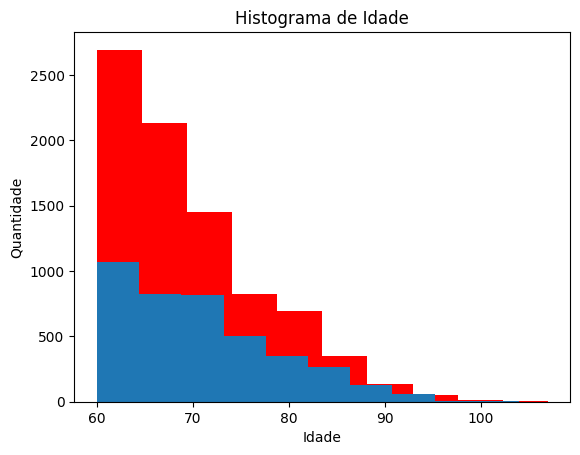

In [9]:
# Plota o histograma da idade das pessoas do DataFrame df_uniao em vermelho
plt.hist(df_uniao['Idade'], color='red')
# Plota o histograma da idade das pessoas com artrite/reumatismo
plt.hist(df_atri_reu['Idade'])
# Adiciona o título ao gráfico
plt.title('Histograma de Idade')
# Adiciona o rótulo do eixo X
plt.xlabel('Idade')
# Adiciona o rótulo do eixo Y
plt.ylabel('Quantidade')
# Exibe o gráfico
plt.show()

### Visualização da distribuição de idade
Esta célula plota histogramas da idade das pessoas saudáveis e das pessoas com artrite/reumatismo, permitindo comparar as distribuições.

Estado
Acre                    82
Alagoas                128
Amapá                   62
Amazonas               126
Bahia                  146
Ceará                  215
Distrito Federal        51
Espírito Santo         170
Goiás                  149
Maranhão               160
Mato Grosso             65
Mato Grosso do Sul     141
Minas Gerais           259
Paraná                 200
Paraíba                158
Pará                   176
Pernambuco             172
Piauí                  136
Rio Grande do Norte    155
Rio Grande do Sul      206
Rio de Janeiro         286
Rondônia                70
Roraima                 43
Santa Catarina         175
Sergipe                122
São Paulo              297
Tocantins               75
Name: count, dtype: int64


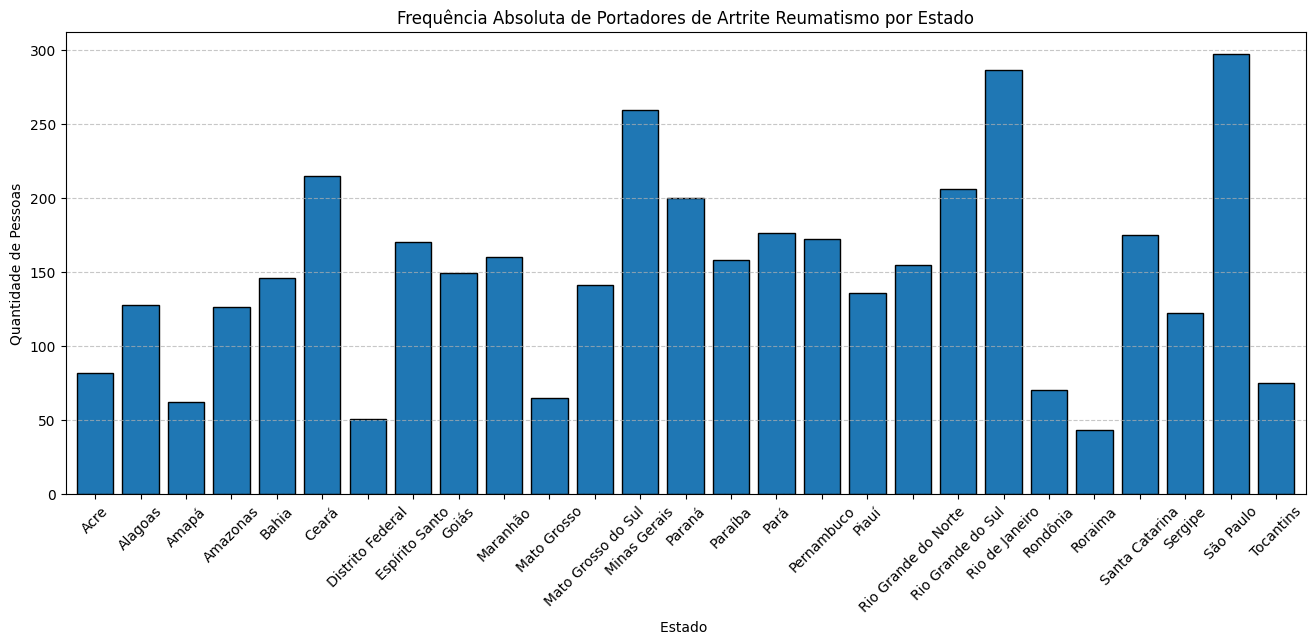

In [10]:
# Conta e plota a frequência absoluta de portadores de artrite/reumatismo por estado
contagem_artrite_reumatismo_es = df_atri_reu['Estado'].value_counts().sort_index()
print(contagem_artrite_reumatismo_es)
# Plota o gráfico de barras
contagem_artrite_reumatismo_es.plot(kind ='bar', edgecolor='black', figsize=(16, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de Artrite Reumatismo por Estado')
plt.xlabel('Estado ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Estado
Acre                    8270
Alagoas                10474
Amapá                   6640
Amazonas               13074
Bahia                  11061
Ceará                  15281
Distrito Federal        7609
Espírito Santo         10673
Goiás                   8506
Maranhão               17912
Mato Grosso             7607
Mato Grosso do Sul      8766
Minas Gerais           15421
Paraná                 11694
Paraíba                10094
Pará                   14393
Pernambuco             12381
Piauí                   9044
Rio Grande do Norte     9964
Rio Grande do Sul      10369
Rio de Janeiro         14776
Rondônia                7391
Roraima                 8476
Santa Catarina         10607
Sergipe                 8140
São Paulo              18504
Tocantins               6599
Name: count, dtype: int64


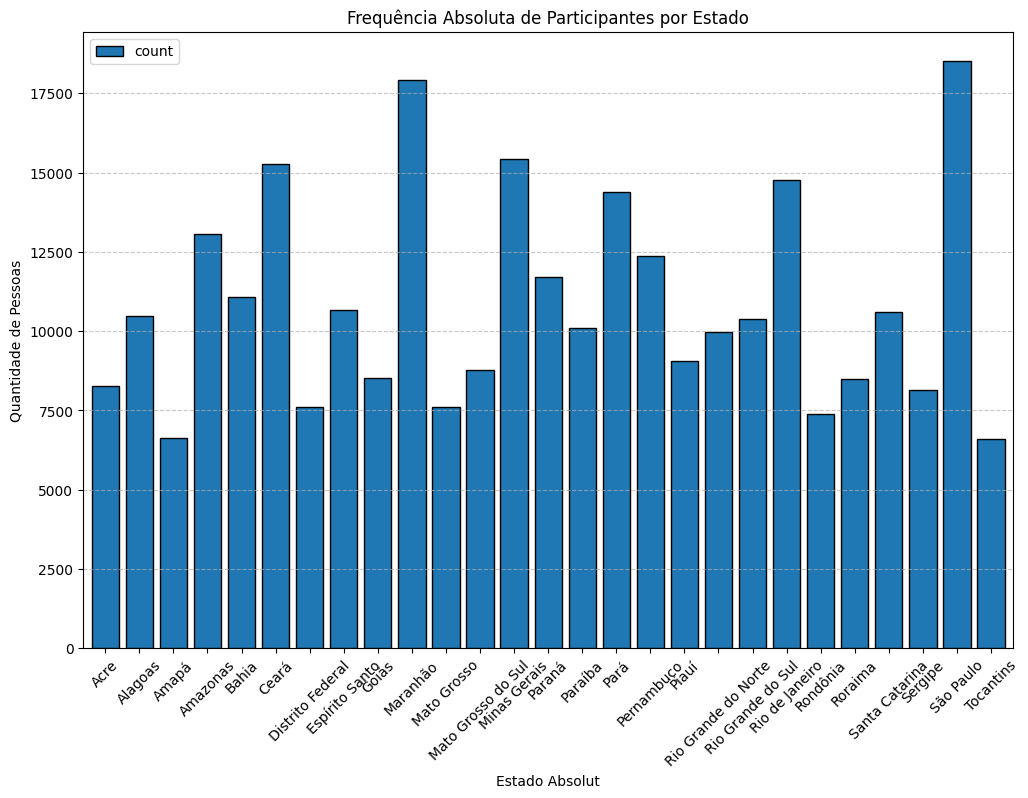

In [11]:
# Conta e plota a frequência absoluta de participantes por estado
contagem_geral_estado = df['Estado'].value_counts().sort_index()
print(contagem_geral_estado)
# Plota o gráfico de barras
contagem_geral_estado.plot(kind ='bar', edgecolor='black', figsize=(12, 8), width=0.8,)
plt.title('Frequência Absoluta de Participantes por Estado')
plt.xlabel('Estado Absolut')
plt.ylabel('Quantidade de Pessoas')
plt.legend()
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

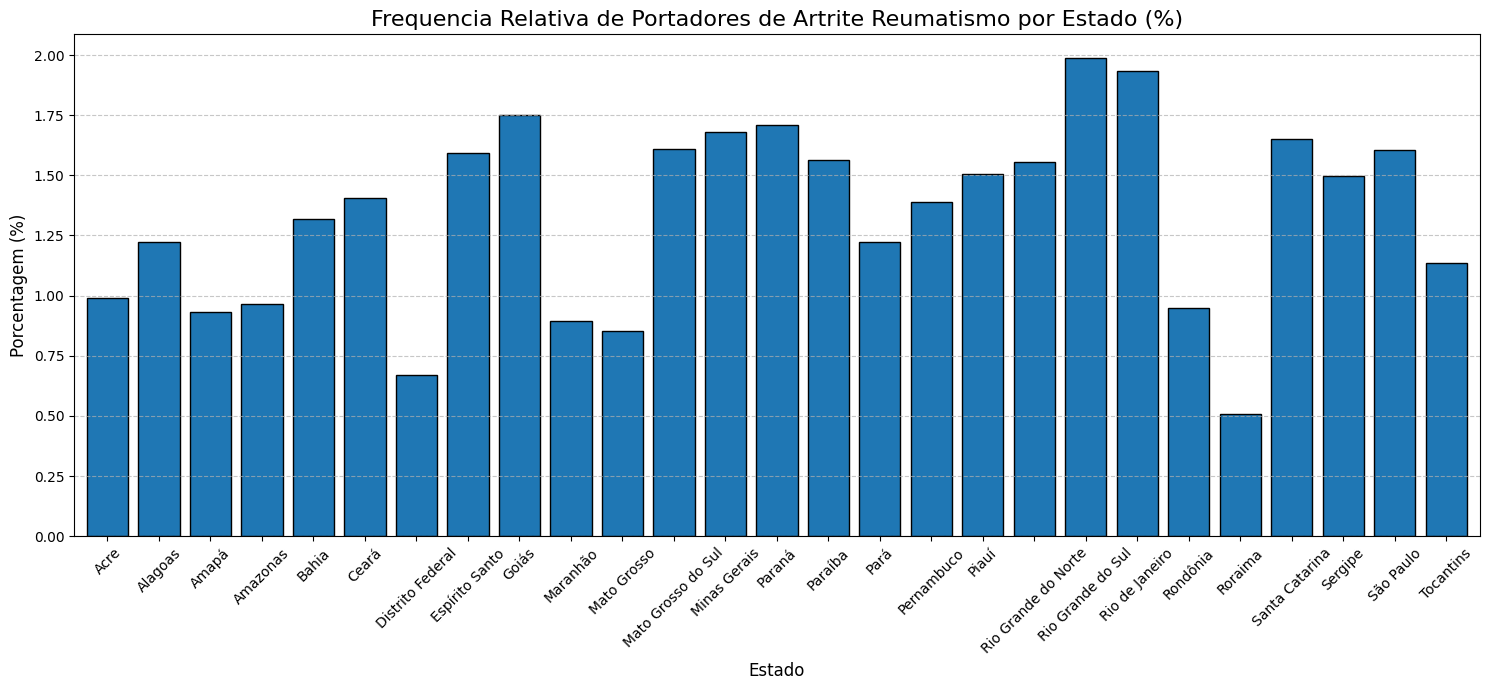

In [12]:
# Calcula e plota a frequência relativa de portadores de artrite/reumatismo por estado
porcentagem_ar_estado = (contagem_artrite_reumatismo_es / contagem_geral_estado) * 100
porcentagem_maior_estado = int(contagem_geral_estado.max() / contagem_geral_estado.sum()* 100)
plt.figure(figsize=(15, 7))
porcentagem_ar_estado.plot(kind='bar', edgecolor='black', width=0.8)
# plt.ylim(0,porcentagem_maior_estado)
plt.title('Frequencia Relativa de Portadores de Artrite Reumatismo por Estado (%)', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

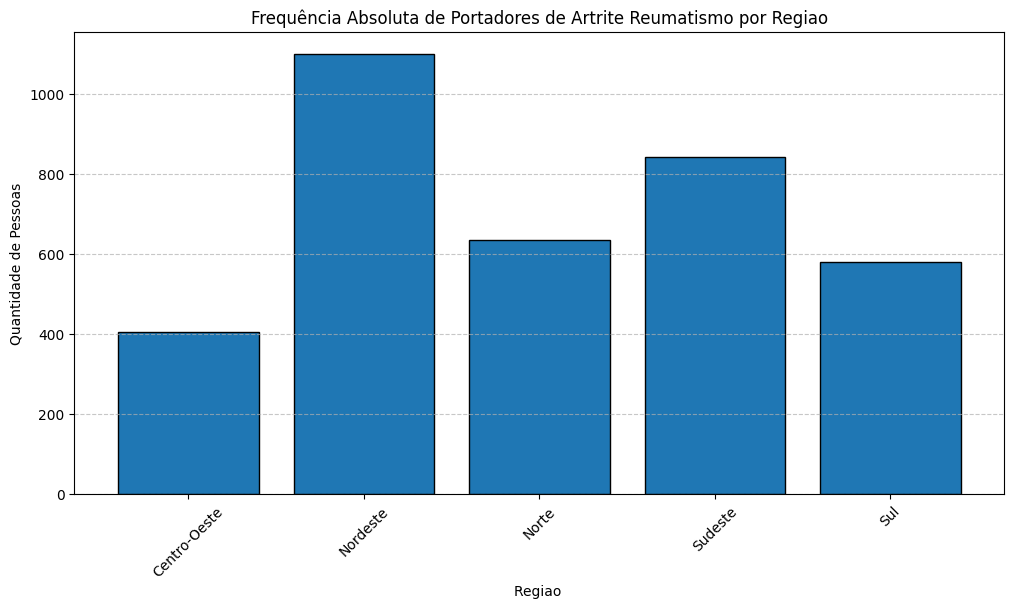

In [13]:
# Conta e plota a frequência absoluta de portadores de artrite/reumatismo por região
contagem_ar_regiao = df_atri_reu['Regiao'].value_counts().sort_index()
contagem_ar_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de Artrite Reumatismo por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

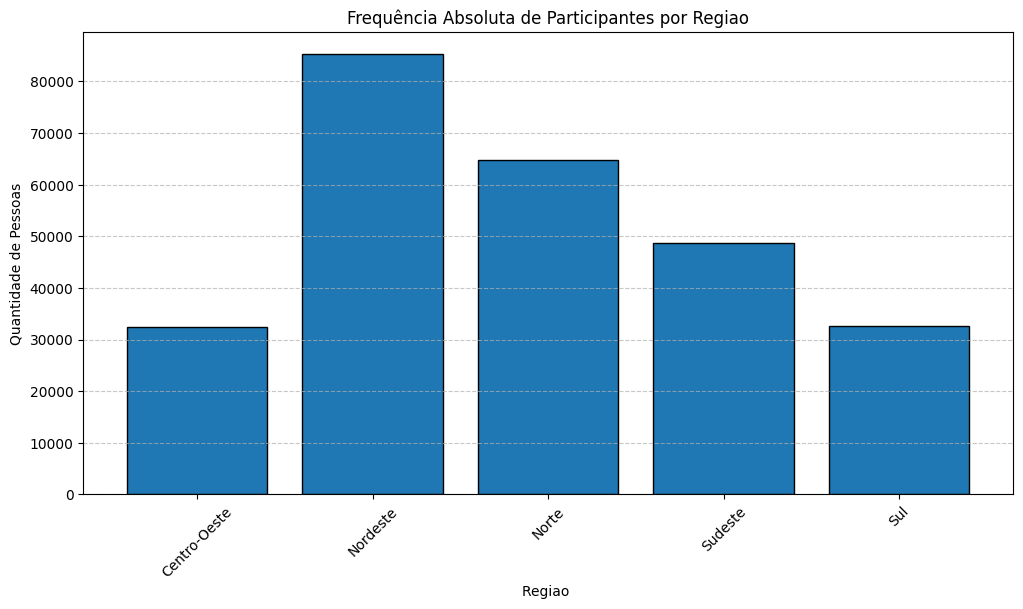

In [14]:
# Conta e plota a frequência absoluta de participantes por região
contagem_geral_regiao = df['Regiao'].value_counts().sort_index()
contagem_geral_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Participantes por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

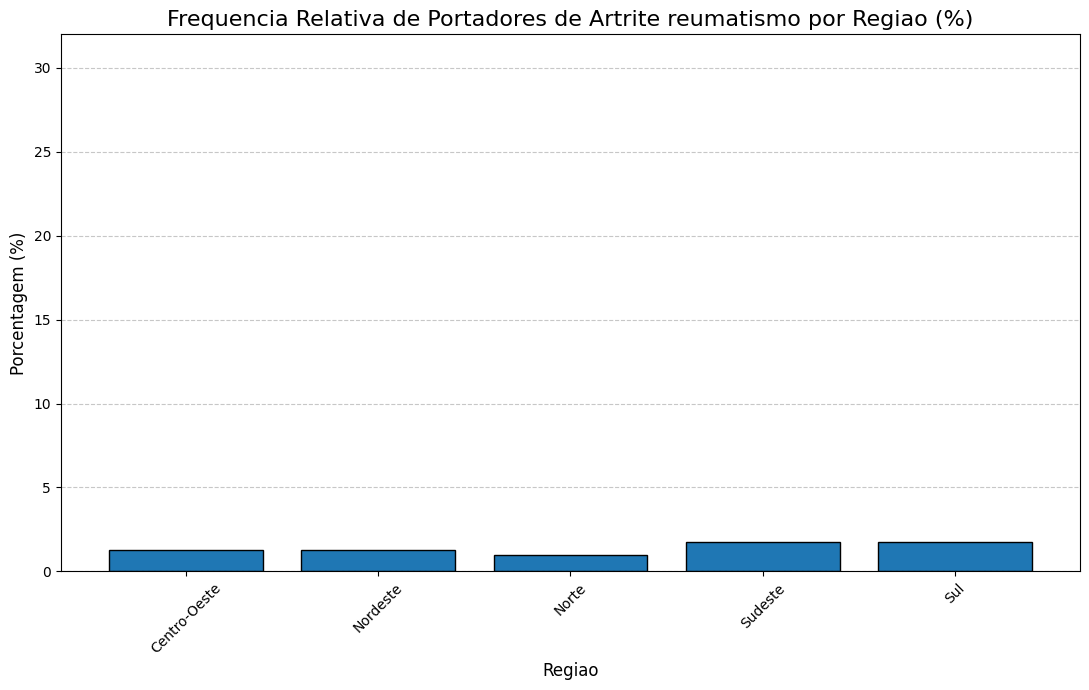

In [15]:
# Calcula e plota a frequência relativa de portadores de artrite/reumatismo por região
porcentagem_ar_estado = (contagem_ar_regiao / contagem_geral_regiao) * 100
porcentagem_maior_estado = int(contagem_geral_regiao.max() / contagem_geral_regiao.sum()* 100)
plt.figure(figsize=(11, 7))
porcentagem_ar_estado.plot(kind='bar', edgecolor='black', width=0.8)
plt.ylim(0,porcentagem_maior_estado)
plt.title('Frequencia Relativa de Portadores de Artrite reumatismo por Regiao (%)', fontsize=16)
plt.xlabel('Regiao', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise geográfica dos dados
Esta célula prepara os dados para análise geográfica, mapeando estados e regiões, e executa a análise visual e estatística para cada grupo de interesse.

In [16]:
# Cria pasta para resultados se não existir
output_dir = "../resultados_analise"  # Caminho da pasta de resultados
os.makedirs(output_dir, exist_ok=True)  # Cria a pasta se não existir
# Função para salvar todos os gráficos, estatísticas, PDF e Word
def salvar_analise_completa(d_geo, nome_grupo):
    # Cria subpasta para o grupo
    grupo_dir = os.path.join(output_dir, nome_grupo.replace(" ", "_"))  # Define o caminho da subpasta
    os.makedirs(grupo_dir, exist_ok=True)  # Cria a subpasta se não existir
    # Salva estatísticas em txt
    with open(os.path.join(grupo_dir, "estatisticas.txt"), "w", encoding="utf-8") as f:
        f.write(f"ANÁLISE GEOGRÁFICA: {nome_grupo}\n")
        f.write("="*60 + "\n\n")
        contagem_regiao = d_geo['Regiao'].value_counts().sort_index()
        f.write("--- Número de Entrevistados por Região ---\n")
        f.write(contagem_regiao.to_string() + "\n\n")
        contagem_estado = d_geo['Estado'].value_counts().sort_index()
        f.write("--- Número de Entrevistados por Estado ---\n")
        f.write(contagem_estado.to_string() + "\n")
    # Gráfico de regiões
    plt.figure(figsize=(8, 4))
    contagem_regiao = d_geo['Regiao'].value_counts().sort_index()
    sns.barplot(x=contagem_regiao.index, y=contagem_regiao.values, palette='viridis')
    plt.title(f'Distribuição por Região - {nome_grupo}')
    plt.ylabel('Número de Idosos')
    plt.xlabel('Região')
    plt.tight_layout()
    plt.savefig(os.path.join(grupo_dir, "grafico_regioes.png"), dpi=300, bbox_inches='tight')
    plt.close()
    # Gráfico de estados
    plt.figure(figsize=(12, 5))
    contagem_estado = d_geo['Estado'].value_counts().sort_index()
    sns.barplot(x=contagem_estado.index, y=contagem_estado.values, palette='magma')
    plt.title(f'Distribuição por Estado - {nome_grupo}')
    plt.ylabel('Número de Idosos')
    plt.xlabel('Estado')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(os.path.join(grupo_dir, "grafico_estados.png"), dpi=300, bbox_inches='tight')
    plt.close()
    # PDF com estatísticas
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=14)
    pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
    pdf.ln(5)
    pdf.set_font("Arial", size=12)
    pdf.cell(0, 10, "Número de Entrevistados por Região", ln=True)
    pdf.set_font("Arial", size=10)
    pdf.cell(60, 8, "Região", 1)
    pdf.cell(40, 8, "Quantidade", 1, ln=True)
    for regiao, qtd in contagem_regiao.items():
        pdf.cell(60, 8, str(regiao), 1)
        pdf.cell(40, 8, str(qtd), 1, ln=True)
    pdf.ln(5)
    pdf.set_font("Arial", size=12)
    pdf.cell(0, 10, "Número de Entrevistados por Estado", ln=True)
    pdf.set_font("Arial", size=10)
    pdf.cell(60, 8, "Estado", 1)
    pdf.cell(40, 8, "Quantidade", 1, ln=True)
    for estado, qtd in contagem_estado.items():
        pdf.cell(60, 8, str(estado), 1)
        pdf.cell(40, 8, str(qtd), 1, ln=True)
    pdf.output(os.path.join(grupo_dir, "estatisticas.pdf"))
    # Word com estatísticas
    doc = Document()
    doc.add_heading(f'ANÁLISE GEOGRÁFICA: {nome_grupo}', 0)
    doc.add_heading('Número de Entrevistados por Região', level=1)
    table_regiao = doc.add_table(rows=1, cols=2)
    hdr_cells = table_regiao.rows[0].cells
    hdr_cells[0].text = 'Região'
    hdr_cells[1].text = 'Quantidade'
    for regiao, qtd in contagem_regiao.items():
        row_cells = table_regiao.add_row().cells
        row_cells[0].text = str(regiao)
        row_cells[1].text = str(qtd)
    doc.add_heading('Número de Entrevistados por Estado', level=1)
    table_estado = doc.add_table(rows=1, cols=2)
    hdr_cells = table_estado.rows[0].cells
    hdr_cells[0].text = 'Estado'
    hdr_cells[1].text = 'Quantidade'
    for estado, qtd in contagem_estado.items():
        row_cells = table_estado.add_row().cells
        row_cells[0].text = str(estado)
        row_cells[1].text = str(qtd)
    doc.save(os.path.join(grupo_dir, "estatisticas.docx"))
    print(f"✓ Análise salva: {nome_grupo}")
# Salva todas as análises
salvar_analise_completa(df, "1_Populacao_Idosa_Geral")
salvar_analise_completa(df_bem, "2_Idosos_Saudaveis")
salvar_analise_completa(df_atri_reu, "3_Idosos_com_Artrite")
salvar_analise_completa(df_atri_reu_puro, "4_Idosos_APENAS_Artrite")
print("\n✓ Todas as análises foram salvas!")

C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_regiao.index, y=contagem_regiao.values, palette='viridis')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_estado.index, y=contagem_estado.values, palette='magma')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:43: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:44: DeprecationWarning: The parameter "ln" i

✓ Análise salva: 1_Populacao_Idosa_Geral


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_estado.index, y=contagem_estado.values, palette='magma')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:43: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:44: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:46: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and

✓ Análise salva: 2_Idosos_Saudaveis


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_estado.index, y=contagem_estado.values, palette='magma')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:43: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:44: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:46: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and

✓ Análise salva: 3_Idosos_com_Artrite


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_estado.index, y=contagem_estado.values, palette='magma')


✓ Análise salva: 4_Idosos_APENAS_Artrite

✓ Todas as análises foram salvas!


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:43: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:44: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:46: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_26960\202979132.py:47: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Número de Entrevistados por Região", ln=True)
C:\Users\Pedro\App

### Salvando resultados da análise
Esta célula salva os resultados das análises (estatísticas e gráficos) em arquivos nas pastas correspondentes a cada grupo, facilitando o compartilhamento e organização dos dados.

In [17]:
# Cria o arquivo ZIP com todos os resultados gerados na análise.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Gera um timestamp para identificar o arquivo ZIP
nome_zip = f"analise_exploratoria_{timestamp}.zip"  # Define o nome do arquivo ZIP com o timestamp
caminho_zip = os.path.join("..", nome_zip)  # Define o caminho onde o ZIP será salvo (um nível acima da pasta atual)
with zipfile.ZipFile(caminho_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:  # Abre o arquivo ZIP para escrita
    for pasta_raiz, pastas, arquivos in os.walk(output_dir):  # Percorre todas as subpastas e arquivos dentro da pasta de resultados
        for arquivo in arquivos:  # Para cada arquivo encontrado
            caminho_completo = os.path.join(pasta_raiz, arquivo)  # Caminho completo do arquivo
            caminho_relativo = os.path.relpath(caminho_completo, output_dir)  # Caminho relativo para manter a estrutura dentro do ZIP
            zipf.write(caminho_completo, caminho_relativo)  # Adiciona o arquivo ao ZIP
print(f"\n🎉 ZIP criado com sucesso: {nome_zip}")  # Mensagem de sucesso ao criar o ZIP
print(f"📁 Localização: {os.path.abspath(caminho_zip)}")  # Mostra o caminho absoluto do arquivo ZIP
print(f"📊 Total de arquivos: {len([f for _, _, files in os.walk(output_dir) for f in files])}")  # Mostra o total de arquivos incluídos no ZIP


🎉 ZIP criado com sucesso: analise_exploratoria_20260309_092634.zip
📁 Localização: c:\Users\Pedro\Desktop\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\analise_exploratoria_20260309_092634.zip
📊 Total de arquivos: 20


## Explicação da célula acima
Esta célula cria um arquivo ZIP contendo todos os resultados gerados na análise exploratória. Ela percorre todas as subpastas e arquivos dentro da pasta de resultados, adicionando-os ao ZIP. O nome do arquivo ZIP inclui um timestamp para facilitar a identificação. Ao final, exibe mensagens informando o sucesso da operação, o caminho do arquivo ZIP e o total de arquivos incluídos.